Josh Lee
Angel Vasquez
Attendance: present for both monday and wednesday
Numerical Algorithm
URL: https://www.kaggle.com/datasets/priyamchoksi/adult-census-income-dataset

In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
#importing file
from google.colab import files #import files
uploaded = files.upload() #upload files

Saving adult.csv to adult (1).csv


In [ ]:
#df adult income dataframe
df = pd.read_csv('adult.csv')
df = df.dropna() #Drops rows with NaN values
df #displays dataframe

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
#Feature Engineering 2: finding x targets and y target
df2 = df[['age', 'hours.per.week', 'income']]

#import label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #creation of label encoder

#label encoding df columns into integers
df2['income'] = le.fit_transform(df2['income']) #creation of label encode for class identification
df2

/tmp/ipykernel_18109/2763323079.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['income'] = le.fit_transform(df2['income']) #creation of label encode for class identification


,age,hours.per.week,income
0,90,40,0
1,82,18,0
2,66,40,0
3,54,40,0
4,41,40,0
...,...,...,...
32556,22,40,0
32557,27,38,0
32558,40,40,1
32559,58,40,0


In [ ]:
#STEP 2: Selecting X and Y Targets and identifying # of classes:

#splitting data into features and target variables:
X = df2[['age', 'hours.per.week']] #X targets: age and hours per week
y = df2['income'] #Y target, income (clases)

#printlines to explain data:
print(f"Total samples in dataset: {len(X)}") #samples in dataset
print(f"Total number of X targets : {X.shape[1]}") #identifies how many targets we have: expected 2: age and hours per week
print(f"Number of classes: {len(np.unique(y))}") #identifies how many classes are present: expected 2: 0 = <=50K, 1 = >50k


Total samples in dataset: 32561
Total number of X targets : 2
Number of classes: 2


In [ ]:
#STEP 3: Splitting Data and training
#Splitting data and training:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2, # 20% for testing = 30 flowers
random_state=42 # Same split every run (reproducible)
)
print("=== STEP 3: Data split into train and test ===")
print(f"Training age and worked hours: {len(X_train)} (model learns from these)")
print(f"Testing age and worked hours: {len(X_test)} (model gets graded on these)")
print()

=== STEP 3: Data split into train and test ===
Training age and worked hours: 26048 (model learns from these)
Testing age and worked hours: 6513 (model gets graded on these)



In [ ]:
# Step 4: Create and TRAIN the Naive Bayes model

#import libraries associated to GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB

# Train the model using the training data
model = GaussianNB() #creation of model varible using gaussianNB algorithm (numerical)
model.fit(X_train, y_train) #model.fit algorithm using x train and y train variables


# Step 5: Make predictions on the test data
y_predicted = model.predict(X_test) #y_predicted variable utilizing model.predict algorithm

# Step 6: Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_predicted) #creation of accuracy variable using acc score algorithm with y test and y pred as perimeters

#Printlines for organization:
print("How accurate is our model?")
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"(Got {int(accuracy * len(y_test))} out of {len(y_test)} samples correct)")
print()

print("Classification Report:")
print(classification_report(y_test, y_predicted))

How accurate is our model?
Accuracy: 76.6%
(Got 4989 out of 6513 samples correct)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86      4976
           1       0.53      0.08      0.13      1537

    accuracy                           0.77      6513
   macro avg       0.65      0.53      0.50      6513
weighted avg       0.72      0.77      0.69      6513



In [ ]:
#confusion matrix text version from example:
cm = confusion_matrix(y_test, y_predicted)
print("=== Confusion Matrix ===")
print("Rows = actual income, Columns = predicted income")
income_labels = ['<=50K', '>50K'] # Define labels for income classes
print(f"{'':15} {income_labels[0]:>10} {income_labels[1]:>12}")
print("-" * 50)
for i, row in enumerate(cm):
    print(f"{income_labels[i]:15} {row[0]:>10} {row[1]:>12}")
print()



=== Confusion Matrix ===
Rows = actual income, Columns = predicted income
                     <=50K         >50K
--------------------------------------------------
<=50K                 4872          104
>50K                  1420          117



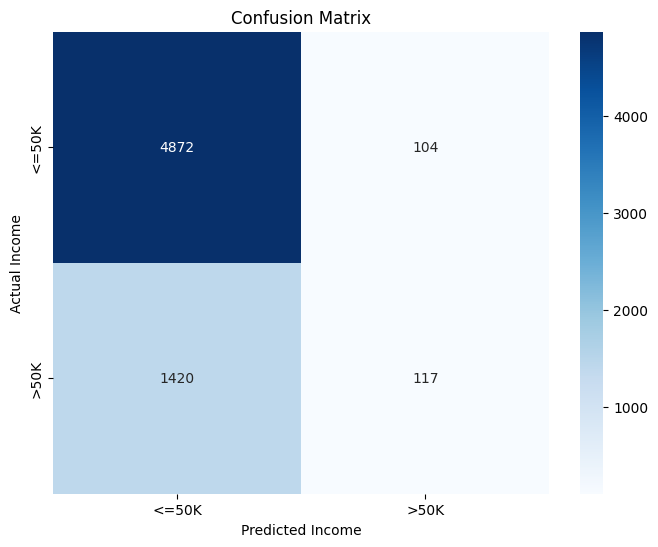

In [ ]:
#Confusion Matrix:

#importing Libraries for confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Confusion Matrix:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=income_labels, yticklabels=income_labels) #labels (<= 50k and >50k)
plt.xlabel('Predicted Income') #x label for predicted income
plt.ylabel('Actual Income') #Y labels for actual income
plt.title('Confusion Matrix') #title of confusion matrix
plt.show() #showcase our confusion matrix

In [ ]:
# Step 7: Predict a BRAND NEW entry (not in the dataset at all)
print("Predict a brand new entry")
print()

#New data entry: (age, work hours/week)
new_entry = [[30, 40]] #new entry variable with age and work hours

# Get prediction
prediction = model.predict(new_entry)[0] # 0 or 1
predicted_income = income_labels[prediction] # Convert to income label
probabilities = model.predict_proba(new_entry)[0] # Probability for each income class

# Printlines for organization of STEP 7:
print(f"New entry details:")
print(f" Age             : {new_entry[0][0]}") #new entry [0], column age: [0]
print(f" Hours per week  : {new_entry[0][1]}") #new entry [0], column work hours: [1]
print()
print(f"Prediction: {predicted_income.upper()}") #prediction label
print()

#print probabliity based on our provided new entry
print(f"Probabilities:")
for i, name in enumerate(income_labels):
    bar = "#" * int(probabilities[i] * 30) # Simple text bar chart
    print(f" {name:12} | {bar:<30} | {probabilities[i]*100:.1f}%")

Predict a brand new entry

New entry details:
 Age             : 30
 Hours per week  : 40

Prediction: <=50K

Probabilities:
 <=50K        | #########################      | 84.3%
 >50K         | ####                           | 15.7%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Report:
We utilize Gaussian Naive Bayes classification model using the Adult Census Income Dataset.  By using the Gaussian Naive Bayes algorithm, we were able to predict whether a person earns less than or equal to 50k OR over 50k based on simple numerical features.  The featuers tested were the person's age and amount of hours worked per week.  Within our algorithm, our system looks through our data and learns typical patterns.  These patterns can include the concept of people working more hours may be more likely to earn a higher income or that age is a correlation with income levels.  Upon learning these patterns, our model makes predictions on individuals based on these 2 parimeters (age and hours worked).  